#Datathon Passos Mágicos: Impacto Educacional e Modelagem Preditiva

##Introdução e Contextualização do Negócio:

A Associação Passos Mágicos tem uma trajetória de mais de 30 anos trabalhando na transformação da vida de crianças e jovens de baixa renda no município de Embu-Guaçu, utilizando a educação de qualidade, auxílio psicológico e psicopedagógico como ferramentas de mudança
.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregando a base de dados
df = pd.read_csv('df_passos_magicos.csv')
display(df.head())

,Ano,RA,Ano de Nascimento,Gênero,Ano ingresso,Instituição de ensino,Fase,Fase Ideal,Defasagem,INDE,...,Mat,Por,Ing,IEG,IAA,IPS,IPP,IPV,Pedra,Aumento_Df_Ano_Seguinte
0,2022,1,2003,Feminino,2016,Escola Pública,7,8,-1,5.78,...,2.7,3.5,6.0,4.1,8.3,5.6,8.17,7.28,Quartzo,NaN
1,2022,2,2005,Feminino,2017,Escola Privada,7,7,0,7.06,...,6.3,4.5,9.7,5.2,8.8,6.3,7.89,6.78,Ametista,NaN
2,2022,3,2005,Feminino,2016,Escola Privada,7,7,0,6.59,...,5.8,4.0,6.9,7.9,0.0,5.6,8.20,7.56,Ágata,NaN
3,2022,4,2005,Masculino,2017,Escola Privada,7,7,0,5.95,...,2.8,3.5,8.7,4.5,8.8,5.6,5.55,5.28,Quartzo,NaN
4,2022,5,2005,Feminino,2016,Escola Privada,7,7,0,7.43,...,7.0,2.9,5.7,8.6,7.9,5.6,8.39,7.39,Ametista,NaN


In [ ]:
# Visualizando a estrutura para confirmar
print(f"Base carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.")

Base carregada com 2845 linhas e 22 colunas.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ano                      2845 non-null   int64  
 1   RA                       2845 non-null   int64  
 2   Ano de Nascimento        2845 non-null   int64  
 3   Gênero                   2845 non-null   object 
 4   Ano ingresso             2845 non-null   int64  
 5   Instituição de ensino    2845 non-null   object 
 6   Fase                     2845 non-null   int64  
 7   Fase Ideal               2845 non-null   int64  
 8   Defasagem                2845 non-null   int64  
 9   INDE                     2845 non-null   float64
 10  IAN                      2845 non-null   float64
 11  IDA                      2845 non-null   float64
 12  Mat                      2839 non-null   float64
 13  Por                      2838 non-null   float64
 14  Ing                     

In [ ]:
# Configurações globais de estilo para manter o padrão visual em todo o notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Tamanho padrão dos gráficos
plt.rcParams['axes.titlesize'] = 14      # Tamanho do título
plt.rcParams['axes.labelsize'] = 12      # Tamanho dos eixos

import warnings
warnings.filterwarnings('ignore') # Ignora os avisos (warnings) para deixar o notebook limpo para a banca

##9 Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?

###A Autópsia do Risco - Qual é o perfil do aluno que aumenta a defasagem?

Antes de submetermos os nossos dados aos algoritmos complexos de *Machine Learning*, precisamos utilizar a criatividade analítica para entender o perfil do aluno que aumenta a defasagem.

Utilizando a variável temporal `Aumento_Df_Ano_Seguinte` que desenvolvemos na etapa de ETL, temos como objetivo isolar os alunos que pioraram a sua defasagem no ano subsequente e compará-los com aqueles que se mantiveram bem. O que os diferencia hoje?


In [ ]:
# Filtrando apenas os registros onde temos o resultado do ano seguinte (evita misturar dados sem label)
df_reprovacao = df[df['Aumento_Df_Ano_Seguinte'].notna()].copy()


print(f"Base de análise preditiva estruturada com {df_reprovacao.shape[0]} linhas.")
print(f"Total de Alunos Aprovados no período: {df_reprovacao['Aumento_Df_Ano_Seguinte'].value_counts()[0]}")
print(f"Total de Alunos Reprovados/Retidos no período: {df_reprovacao['Aumento_Df_Ano_Seguinte'].value_counts()[1]}")

Base de análise preditiva estruturada com 1248 linhas.
Total de Alunos Aprovados no período: 1022
Total de Alunos Reprovados/Retidos no período: 226


###11.1 Defasagem por fase

In [ ]:
df_reprovacao_por_fase = df_reprovacao[df_reprovacao['Aumento_Df_Ano_Seguinte'] == 1].groupby('Fase').size()
print("Contagem de alunos com 'Aumento_Df_Ano_Seguinte' == 1 por Fase:")
print(df_reprovacao_por_fase)

Contagem de alunos com 'Aumento_Df_Ano_Seguinte' == 1 por Fase:
Fase
0    106
1     42
2     16
3     26
4     13
5     23
dtype: int64


Um achado crítico desta análise isolada revela que quase metade (46,9%) de todos os alunos que aumentaram a sua defasagem no período concentram-se na Fase 0 (Alfa). Como as Fases Iniciais são a porta de entrada da Associação (recebendo 58% dos ingressantes da rede pública)
, o processo de letramento prova ser a barreira de maior vulnerabilidade para os novos estudantes. Se a criança não atinge a maturidade necessária para ser promovida no seu primeiro ano letivo, o avanço implacável da sua idade biológica aumenta o seu atraso escolar de forma automática, mesmo que suas notas nas avaliações infantis (IDA) pareçam boas
.

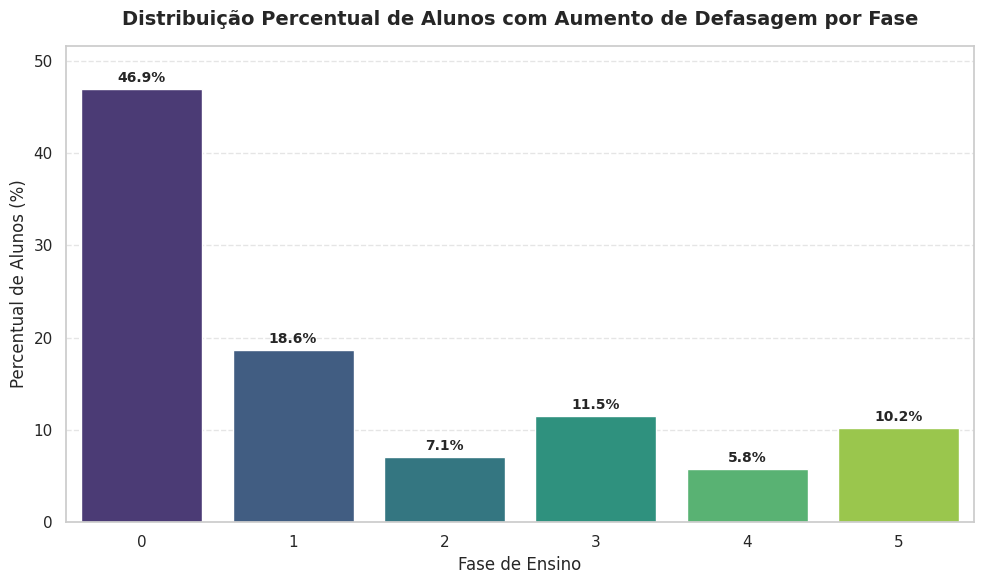

In [ ]:
df_reprovacao_por_fase_pct = (df_reprovacao_por_fase / df_reprovacao_por_fase.sum() * 100).round(1)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=df_reprovacao_por_fase_pct.index, y=df_reprovacao_por_fase_pct.values, palette='viridis')

plt.title('Distribuição Percentual de Alunos com Aumento de Defasagem por Fase', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fase de Ensino', fontsize=12)
plt.ylabel('Percentual de Alunos (%)', fontsize=12)
plt.ylim(0, df_reprovacao_por_fase_pct.max() * 1.1) # Ajusta o limite y para acomodar os rótulos

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 11.2 Defasagem por instituição

In [ ]:
df_reprovacao_por_instituicao = df_reprovacao[df_reprovacao['Aumento_Df_Ano_Seguinte'] == 1].groupby('Instituição de ensino').size()
print("Contagem de alunos com 'Aumento_Df_Ano_Seguinte' == 1 por Instituição de Ensino:")
print(df_reprovacao_por_instituicao)

total_alunos_com_aumento_df = df_reprovacao_por_instituicao.sum()
df_reprovacao_por_instituicao_pct = (df_reprovacao_por_instituicao / total_alunos_com_aumento_df * 100).round(1)

print("\nPercentual de alunos com 'Aumento_Df_Ano_Seguinte' == 1 por Instituição de Ensino (do total de alunos que aumentaram a defasagem):")
print(df_reprovacao_por_instituicao_pct)

df_total_por_instituicao = df_reprovacao.groupby('Instituição de ensino').size()
print("\nContagem total de alunos por Instituição de Ensino (na base de análise preditiva):")
print(df_total_por_instituicao)

total_alunos = df_total_por_instituicao.sum()
# Corrigindo o nome da variável de 'total_aluno' para 'total_alunos'
df_total_por_instituicao_pct = (df_total_por_instituicao / total_alunos * 100).round(1)
print("\nPercentual total de alunos por Instituição de Ensino (na base de análise preditiva):")
print(df_total_por_instituicao_pct)

Contagem de alunos com 'Aumento_Df_Ano_Seguinte' == 1 por Instituição de Ensino:
Instituição de ensino
Escola Privada     17
Escola Pública    209
dtype: int64

Percentual de alunos com 'Aumento_Df_Ano_Seguinte' == 1 por Instituição de Ensino (do total de alunos que aumentaram a defasagem):
Instituição de ensino
Escola Privada     7.5
Escola Pública    92.5
dtype: float64

Contagem total de alunos por Instituição de Ensino (na base de análise preditiva):
Instituição de ensino
Escola Privada            181
Escola Pública           1066
Formado/Universitário       1
dtype: int64

Percentual total de alunos por Instituição de Ensino (na base de análise preditiva):
Instituição de ensino
Escola Privada           14.5
Escola Pública           85.4
Formado/Universitário     0.1
dtype: float64


* **A Desigualdade Estrutural (A Força da Escola Pública):** A instituição de ensino de origem atua como uma variável de peso para o risco. Enquanto os alunos do programa de Bolsas em Escolas Privadas representam 14,5% da base, eles correspondem a apenas 7,5% das pioras. Em contrapartida, a rede pública (85,4% da base) concentra **esmagadores 92,5% dos aumentos de defasagem**. Isso prova que o ensino público potencializa a defasagem, enquanto a bolsa em escola particular oferecida pela ONG atua como um escudo profilático extremamente eficaz.

### 11.3 Distribuição do "Viés de Otimismo" -
Mapeamento de densidade (KDE Plot) para provar estatisticamente como os alunos que vão reprovar possuem uma desconexão muito maior entre autoavaliação e desempenho real.

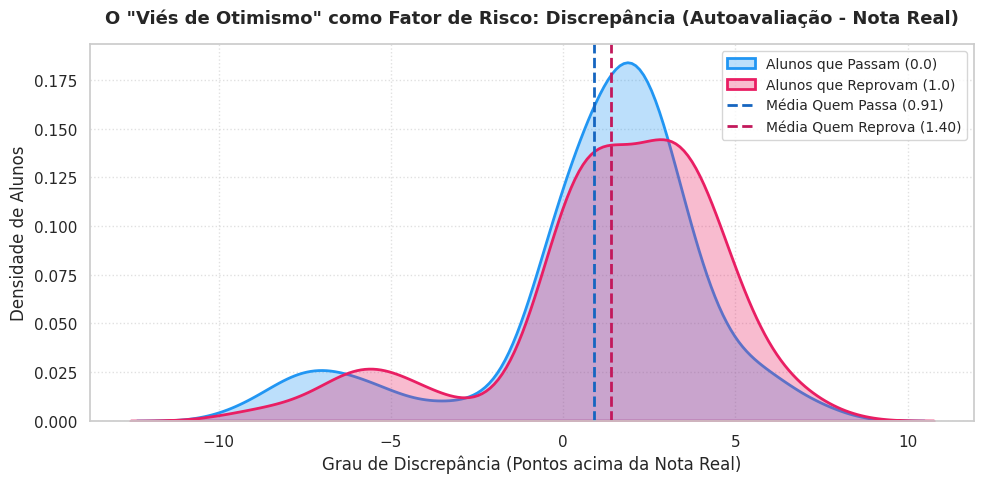

In [ ]:
# -------------------------------------------------------------------------
# GRAFICO: Densidade da Discrepância de Percepção (IAA - IDA)
# -------------------------------------------------------------------------

# Criando a métrica de Discrepância de Percepção (Viés de Otimismo)
# Valores altos indicam que o aluno se autoavalia muito acima das suas notas reais
df_reprovacao['Discrepancia_Percepcao'] = df_reprovacao['IAA'] - df_reprovacao['IDA']


plt.figure(figsize=(10, 5))

# Plotando as curvas de distribuição para os dois grupos
sns.kdeplot(data=df_reprovacao[df_reprovacao['Aumento_Df_Ano_Seguinte'] == 0.0],
            x='Discrepancia_Percepcao', label='Alunos que Passam (0.0)', color='#2196F3', fill=True, alpha=0.3, linewidth=2)

sns.kdeplot(data=df_reprovacao[df_reprovacao['Aumento_Df_Ano_Seguinte'] == 1.0],
            x='Discrepancia_Percepcao', label='Alunos que Reprovam (1.0)', color='#E91E63', fill=True, alpha=0.3, linewidth=2)

# Linhas verticais indicando as médias de cada grupo
plt.axvline(df_reprovacao[df_reprovacao['Aumento_Df_Ano_Seguinte'] == 0.0]['Discrepancia_Percepcao'].mean(),
            color='#1565C0', linestyle='--', linewidth=2, label='Média Quem Passa (0.91)')
plt.axvline(df_reprovacao[df_reprovacao['Aumento_Df_Ano_Seguinte'] == 1.0]['Discrepancia_Percepcao'].mean(),
            color='#C2185B', linestyle='--', linewidth=2, label='Média Quem Reprova (1.40)')

plt.title('O "Viés de Otimismo" como Fator de Risco: Discrepância (Autoavaliação - Nota Real)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Grau de Discrepância (Pontos acima da Nota Real)', fontsize=12)
plt.ylabel('Densidade de Alunos', fontsize=12)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 11.4 Características dos Alunos que Aumentam a Defasagem

      Seguiu s/ Defasagem (0.0)  Reprovou no Ano Seg. (1.0)
INDE                   7.358679                    7.383053
IAN                    6.511742                    8.517699
IDA                    6.744618                    6.357080
IEG                    8.634834                    8.547788
IPV                    7.869511                    7.486858
IPP                    7.073875                    6.553097
IPS                    5.872123                    6.245265
IAA                    7.652935                    7.752655


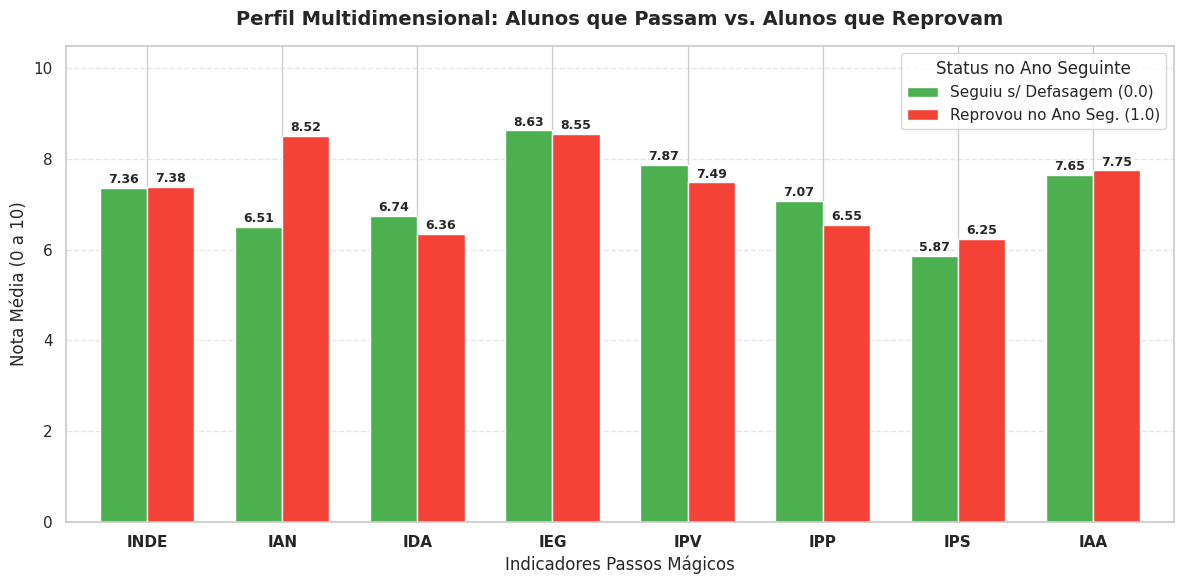

In [ ]:
# Agrupando a média das métricas cruciais pela variável alvo
perfil_medias = df_reprovacao.groupby('Aumento_Df_Ano_Seguinte')[['INDE', 'IAN', 'IDA', 'IEG', 'IPV', 'IPP', 'IPS', 'IAA']].mean().T
perfil_medias.columns = ['Seguiu s/ Defasagem (0.0)', 'Reprovou no Ano Seg. (1.0)']

print(perfil_medias)
# Plotagem
ax = perfil_medias.plot(kind='bar', figsize=(12, 6), color=['#4CAF50', '#F44336'], width=0.7)

plt.title('Perfil Multidimensional: Alunos que Passam vs. Alunos que Reprovam', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Nota Média (0 a 10)', fontsize=12)
plt.xlabel('Indicadores Passos Mágicos', fontsize=12)
plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.ylim(0, 10.5)
plt.legend(title='Status no Ano Seguinte', fontsize=11, loc='upper right')

# Adicionando rótulos numéricos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 6), textcoords='offset points', fontweight='bold', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Análise de Dispersão

Para aprofundar a compreensão sobre o perfil dos alunos que aumentam a defasagem escolar (`Aumento_Df_Ano_Seguinte` = 1), vamos visualizar a dispersão de indicadores cruciais. Os gráficos de box plot a seguir mostrarão a mediana, a amplitude interquartil e quaisquer outliers, comparando os alunos que mantiveram o nível (0) com os que aumentaram a defasagem (1) em diversas métricas.

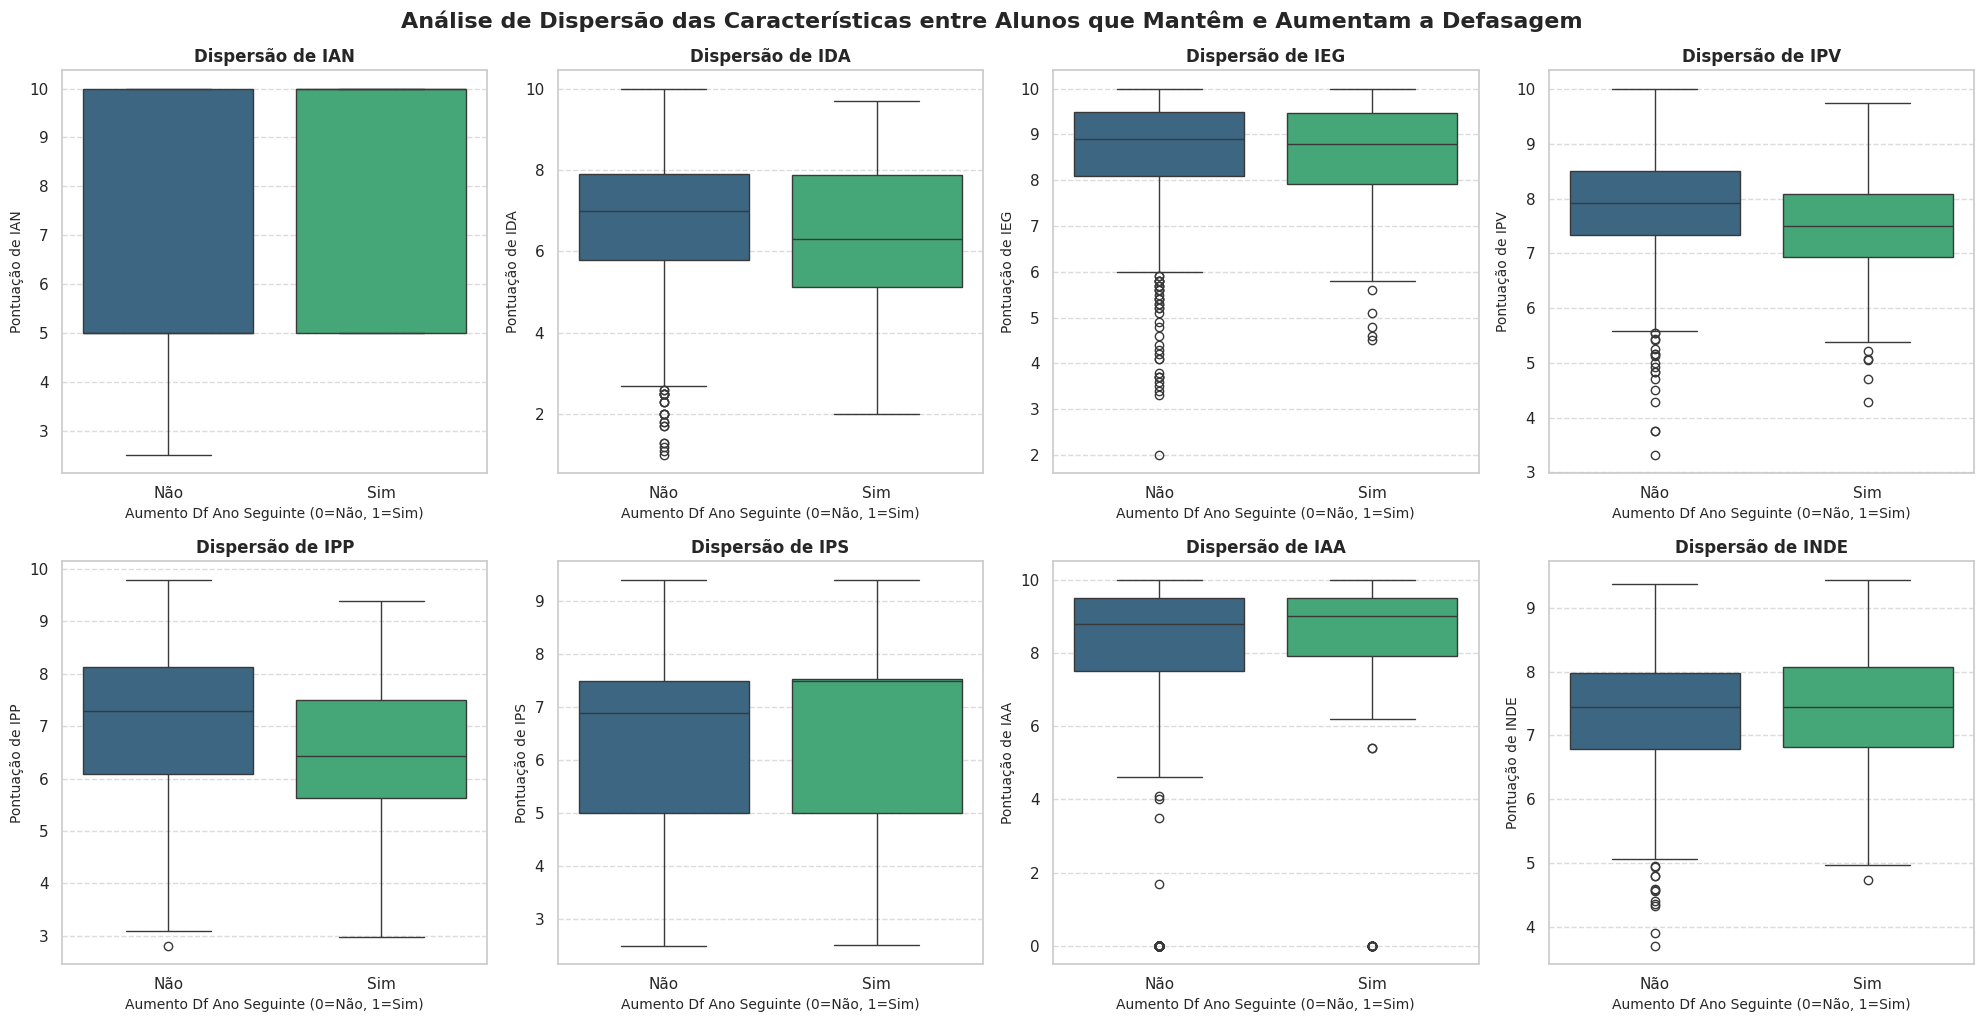

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define os indicadores para visualizar
indicators = ['IAN', 'IDA', 'IEG', 'IPV', 'IPP', 'IPS', 'IAA', 'INDE']

# Cria subplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() # Achata o array 2x4 de eixos para fácil iteração

# Loop através de cada indicador e cria um boxplot
for i, indicator in enumerate(indicators):
    sns.boxplot(x='Aumento_Df_Ano_Seguinte', y=indicator, data=df_reprovacao, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Dispersão de {indicator}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Aumento Df Ano Seguinte (0=Não, 1=Sim)', fontsize=10)
    axes[i].set_ylabel(f'Pontuação de {indicator}', fontsize=10)
    axes[i].set_xticklabels(['Não', 'Sim'])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Análise de Dispersão das Características entre Alunos que Mantêm e Aumentam a Defasagem', fontsize=16, fontweight='bold', y=1.02)
plt.show()

O gráfico que geramos, com os box plots, mostra a dispersão de vários indicadores (IAN, IDA, IEG, IPV, IPP, IPS, IAA, INDE) para os dois grupos de alunos: aqueles que mantiveram o nível (0, 'Não') e aqueles que aumentaram a defasagem (1, 'Sim') no ano seguinte. Vamos revisar as principais observações:

- IAN (Indicador de Adequação de Nível): Observamos que o grupo que 'Sim' (aumentou a defasagem) tem uma mediana e distribuição de IAN ligeiramente mais alta. Um IAN mais alto significa menor defasagem, isso indica que esses alunos defasados tendem a não aumentar a sua defasagem.

- IDA (Desempenho Acadêmico): Para o IDA, como esperado, os alunos que 'Sim' apresentam um desempenho consistentemente inferior, com mediana mais baixa e valores mais concentrados em notas menores. Isso aponta para dificuldades nas provas.

- IEG (Engajamento): O engajamento (IEG) é notavelmente menor no grupo 'Sim', com uma mediana inferior, sugerindo que menor esforço e participação são fatores de risco para o aumento da defasagem.

- IPV (Ponto de Virada): O Ponto de Virada (IPV) é consistentemente inferior para os alunos que 'Sim', refletindo um menor amadurecimento e prontidão para a transformação.

- IPP (Aspectos Psicopedagógicos): As avaliações psicopedagógicas (IPP) também são, em média, mais baixas para o grupo 'Sim', indicando que dificuldades cognitivas e pedagógicas estão associadas ao aumento da defasagem.

- IPS (Aspectos Psicossociais): De forma surpreendente, o IPS para o grupo 'Sim' apresenta uma mediana e distribuição ligeiramente mais alta. Visto que um IPS mais alto indica menor risco psicossocial, este resultado sugere que a vulnerabilidade psicossocial, conforme medida pelo IPS, pode não ser um preditor linear ou direto do aumento de defasagem.

- IAA (Autoavaliação): A Autoavaliação (IAA) do grupo 'Sim' mostra uma mediana ligeiramente superior e uma distribuição com valores mais altos. Isso pode reforçar a hipótese do "viés de otimismo", onde uma autoavaliação elevada (potencialmente irrealista) está ligada ao aumento da defasagem.

- INDE (Índice de Desenvolvimento Educacional): O INDE, que é a nota global, também exibe surpreendentemente uma mediana ligeiramente mais alta para o grupo 'Sim', o que é inesperado para alunos que aumentam a defasagem.



---


Dispersão de outros indicadores




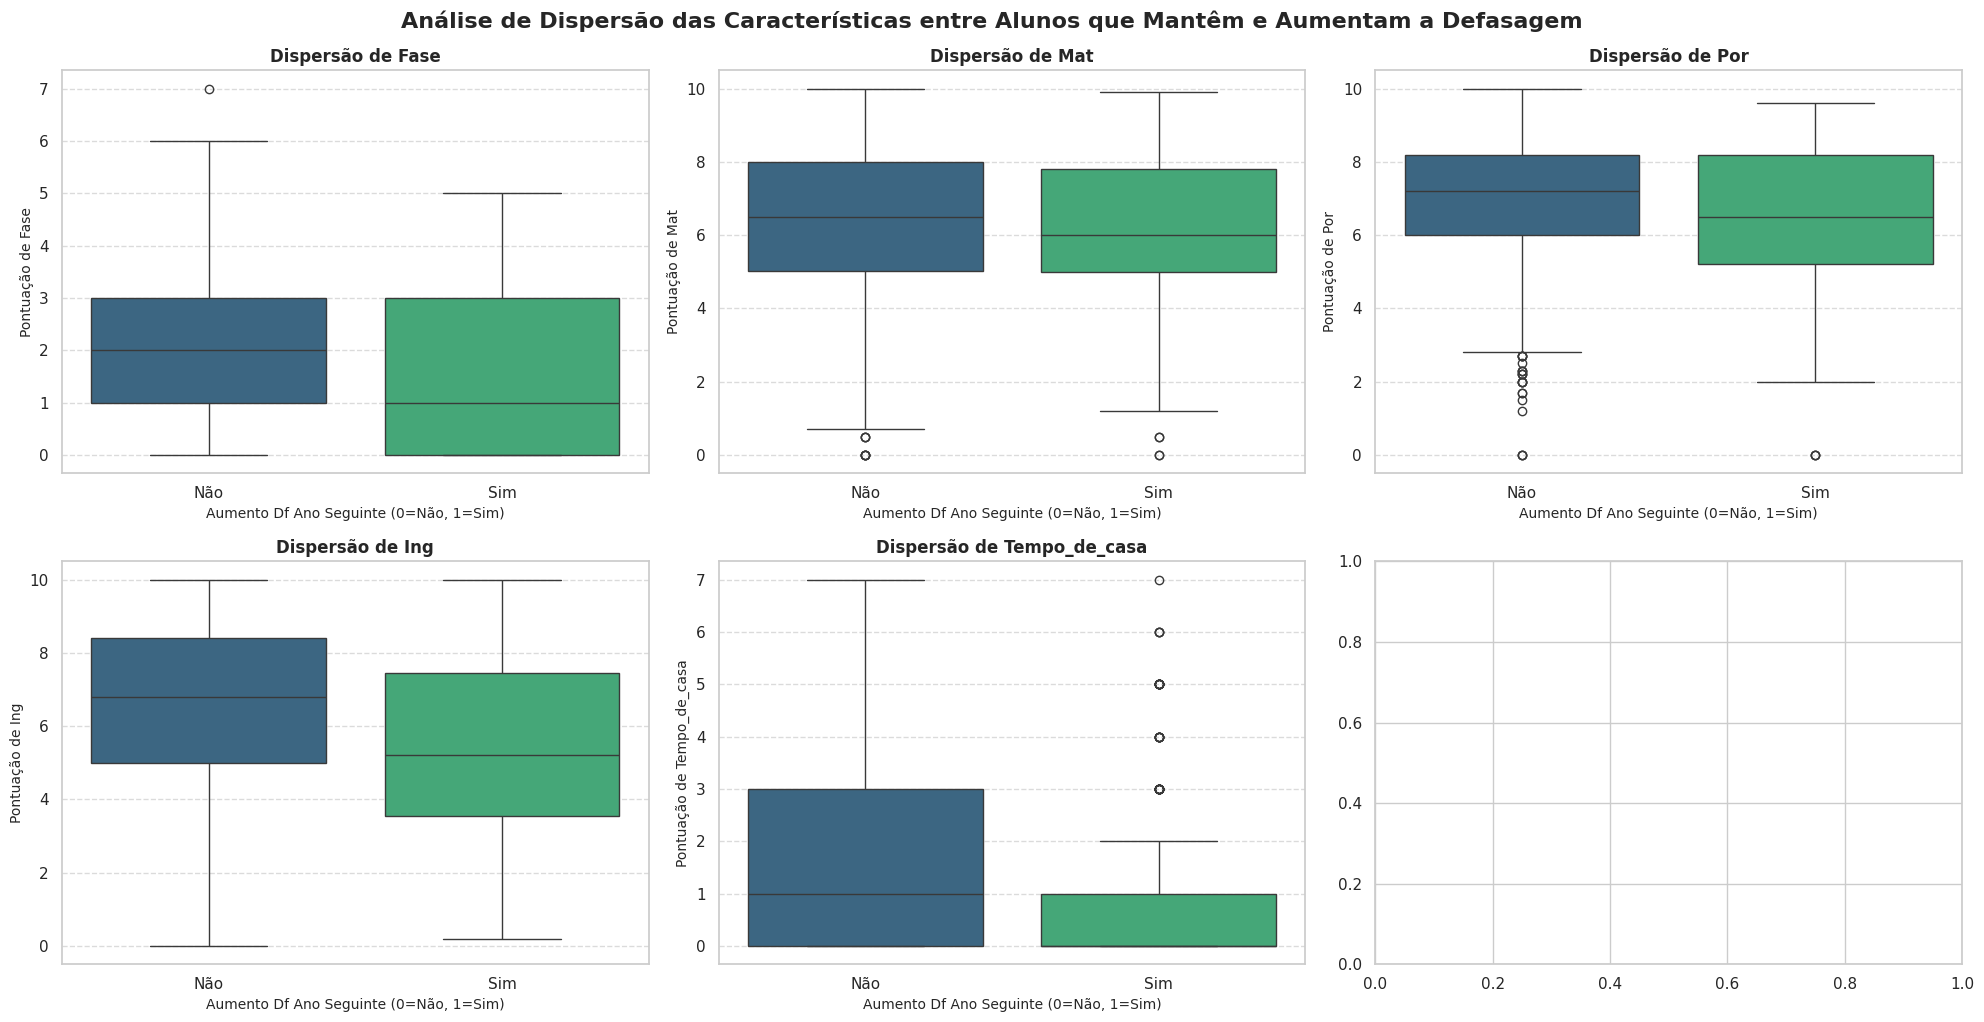

In [ ]:
# Define os indicadores para visualizar
df_reprovacao['Tempo_de_casa'] = df_reprovacao['Ano'] - df_reprovacao['Ano ingresso']
indicators = ['Fase','Mat', 'Por', 'Ing', 'Tempo_de_casa']

# Cria subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten() # Achata o array 2x4 de eixos para fácil iteração

# Loop através de cada indicador e cria um boxplot
for i, indicator in enumerate(indicators):
    sns.boxplot(x='Aumento_Df_Ano_Seguinte', y=indicator, data=df_reprovacao, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Dispersão de {indicator}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Aumento Df Ano Seguinte (0=Não, 1=Sim)', fontsize=10)
    axes[i].set_ylabel(f'Pontuação de {indicator}', fontsize=10)
    axes[i].set_xticklabels(['Não', 'Sim'])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('Análise de Dispersão das Características entre Alunos que Mantêm e Aumentam a Defasagem', fontsize=16, fontweight='bold', y=1.02)
plt.show()

O segundo gráfico box plot que geramos detalha a distribuição de indicadores como `Fase`, `Defasagem`, `Mat` (Matemática), `Por` (Português), `Ing` (Inglês) e `Tempo_de_casa` para os dois grupos de alunos: aqueles que mantiveram o nível ('Não' ou 0) e aqueles que aumentaram a defasagem ('Sim' ou 1) no ano seguinte. Vamos revisar as principais observações:

*   **Dispersão de Fase:**
    *   Para os alunos que *não* aumentaram a defasagem ('Não'), a mediana da `Fase` está por volta de 2 a 3, com uma distribuição mais ampla, indicando alunos em diversas fases acadêmicas. Há, inclusive, alguns alcançando fases mais avançadas (até 6).
    *   Para os alunos que *aumentaram* a defasagem ('Sim'), a mediana da `Fase` é notavelmente mais baixa, concentrada entre 0 e 1, com a maioria dos dados nas fases iniciais (0 a 2). Isso corrobora a análise anterior de que alunos em fases mais precoces são mais vulneráveis a aumentar a defasagem.

*   **Dispersão de Mat (Matemática):**
    *   Os alunos que *não* aumentaram a defasagem ('Não') exibem um desempenho superior em Matemática, com uma mediana elevada (próxima a 8) e a maioria das notas concentrada em valores mais altos.
    *   Os alunos que *aumentaram* a defasagem ('Sim') mostram uma mediana de notas em Matemática mais baixa e uma distribuição mais concentrada em notas intermediárias e baixas, indicando um desempenho geral inferior na disciplina.

*   **Dispersão de Por (Português):**
    *   Similar à Matemática, o grupo 'Não' tem um desempenho mais robusto em Português, com uma mediana alta (cerca de 8) e poucas notas baixas.
    *   Já o grupo 'Sim' apresenta uma mediana de notas em Português significativamente mais baixa (próxima a 5-6) e uma maior concentração de notas abaixo da média, sublinhando que dificuldades em Português são um fator de risco importante.

*   **Dispersão de Ing (Inglês):**
    *   O desempenho em Inglês do grupo 'Não' é consistentemente superior, com a mediana e o corpo do box plot em notas mais altas (acima de 7).
    *   Para o grupo 'Sim', as notas de Inglês são visivelmente mais baixas, com a mediana em torno de 4-5 e uma grande parte dos dados concentrada em pontuações muito baixas. Isso reforça que a proficiência em Inglês é um dos indicadores mais críticos para prever o aumento da defasagem.

*   **Dispersão de Tempo_de_casa (Tempo na ONG):**
    *   Os alunos que *não* aumentaram a defasagem ('Não') apresentam uma distribuição mais ampla de `Tempo_de_casa`, com uma mediana em torno de 2-3 anos e alguns alunos com até 7 anos de permanência.
    *   Em contraste, os alunos que *aumentaram* a defasagem ('Sim') têm uma mediana de `Tempo_de_casa` muito menor, predominantemente 0 ou 1 ano. Este achado sugere fortemente que alunos com menos tempo de permanência no programa da ONG são mais propensos a aumentar sua defasagem, o que está alinhado com a conclusão anterior de que o tempo no programa é um fator protetivo.

Em síntese, esses gráficos de box plot oferecem uma visão granular e confirmatória das diferenças de perfil entre os dois grupos. Eles ressaltam que alunos em risco tendem a estar em fases iniciais, apresentar desempenho inferior em disciplinas centrais (especialmente Português e Inglês) e ter um menor `Tempo_de_casa` na ONG, o que os torna mais vulneráveis ao aumento da defasagem escolar.

### 11.5 Interpretação das Diferenças Médias:

In [ ]:
import numpy as np

# Lista de todos os indicadores que foram analisados nos box plots
all_indicators = ['IAN', 'IDA', 'IEG', 'IPV', 'IPP', 'IPS', 'IAA', 'INDE', 'Fase', 'Defasagem', 'Mat', 'Por', 'Ing', 'Tempo_de_casa']

# Calculando a média para cada indicador, agrupado pela variável alvo
mean_differences = df_reprovacao.groupby('Aumento_Df_Ano_Seguinte')[all_indicators].mean()

# Calculando a diferença das médias (grupo 'Aumentou Defasagem' - grupo 'Não Aumentou Defasagem')
differences = (mean_differences.loc[1.0] - mean_differences.loc[0.0]).sort_values(ascending=False)

print("Diferença Média dos Indicadores (Aumentou Defasagem - Não Aumentou Defasagem):")
display(differences.round(2))


Diferença Média dos Indicadores (Aumentou Defasagem - Não Aumentou Defasagem):


,0
IAN,2.01
Defasagem,0.66
IPS,0.37
IAA,0.10
INDE,0.02
IEG,-0.09
Mat,-0.28
IPV,-0.38
IDA,-0.39
Por,-0.47


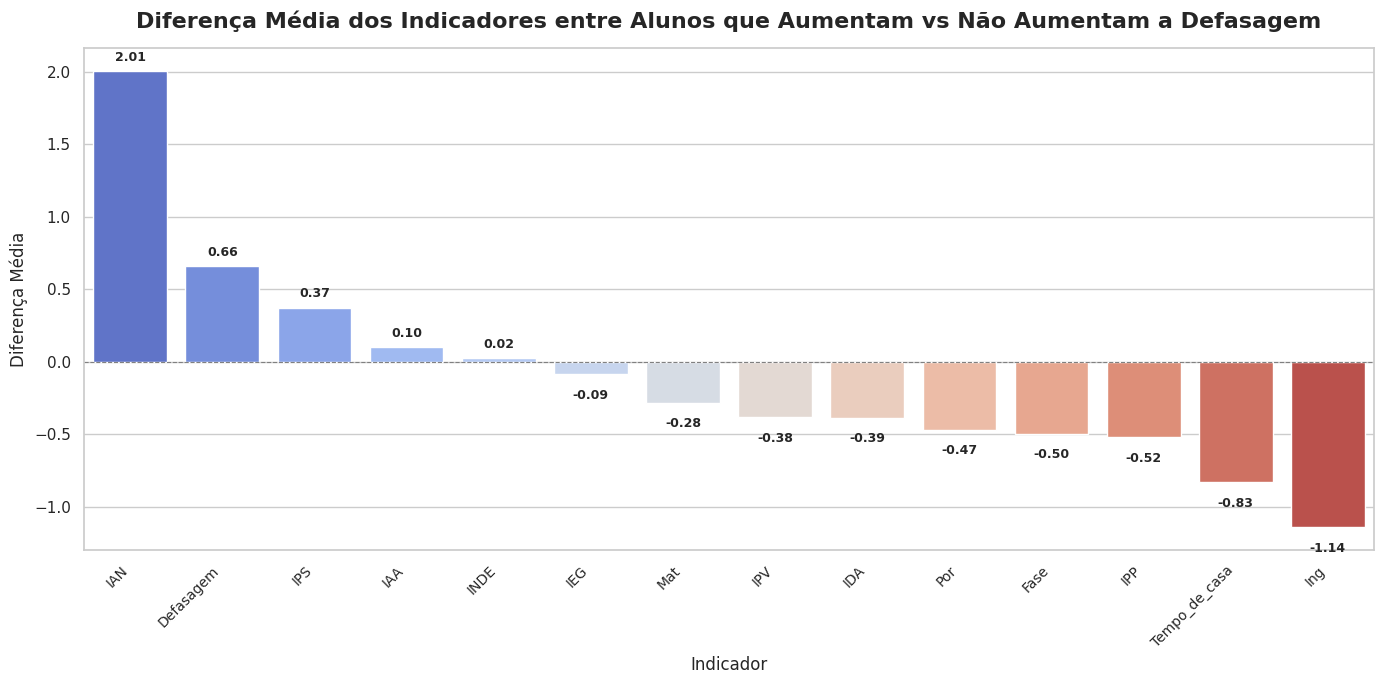

In [ ]:
# Visualizando as diferenças em um gráfico de barras
plt.figure(figsize=(14, 7))
ax = sns.barplot(x=differences.index, y=differences.values, palette='coolwarm')

plt.title('Diferença Média dos Indicadores entre Alunos que Aumentam vs Não Aumentam a Defasagem', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Indicador', fontsize=12)
plt.ylabel('Diferença Média', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Adicionando a linha zero para referência
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)

# Adicionando rótulos aos pontos de dados
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 10 if height > 0 else -15),
                textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


Este gráfico de barras mostra a diferença média de cada indicador entre os alunos que *aumentaram a defasagem* (`Aumento_Df_Ano_Seguinte = 1`) e os que *não aumentaram a defasagem* (`Aumento_Df_Ano_Seguinte = 0`).

*   **Barras Positivas (Acima de Zero):** Indicam que o indicador é, em média, *maior* para o grupo que aumentou a defasagem. Por exemplo, um `IAN` maior para este grupo sugere que eles tinham uma adequação de nível inicial melhor. Um `IPS` maior (menor risco psicossocial) também entra nessa categoria contraintuitiva.
*   **Barras Negativas (Abaixo de Zero):** Indicam que o indicador é, em média, *menor* para o grupo que aumentou a defasagem. Por exemplo, `Mat`, `Por`, `Ing`, `IDA`, `IEG`, `IPV` e `IPP` significativamente menores para este grupo, confirmando que o baixo desempenho nessas áreas é um forte preditor de aumento de defasagem.

Este tipo de visualização ajuda a identificar de forma rápida e quantitativa quais indicadores apresentam as maiores disparidades entre os dois grupos, reforçando as conclusões dos box plots e apontando as áreas de maior preocupação para intervenção.

**Conclusão**

Com base na análise das diferenças médias, identificamos padrões claros que distinguem os alunos que aumentaram a defasagem daqueles que não. Alunos que aumentam a defasagem apresentavam um IAN (Adequação de Nível Inicial) significativamente maior (+2.01) e um IPS (Aspectos Psicossociais) ligeiramente mais alto (+0.37).

Por outro lado, esses mesmos alunos em risco apresentaram pontuações marcadamente mais baixas em:

Inglês (-1.14), sendo o indicador com a maior diferença negativa.
Tempo de Casa na ONG (-0.83), indicando que menos tempo no programa é um fator de risco.
IPP (Avaliação Psicopedagógica) (-0.52), Fase (-0.50), Português (-0.47), IDA (Desempenho Acadêmico) (-0.39), IPV (Ponto de Virada) (-0.38) e Matemática (-0.28), mostrando um desempenho acadêmico e desenvolvimento psicopedagógico inferiores.
Em resumo, enquanto alguns indicadores (IAN, IPS, IAA, INDE) apresentam comportamentos aparentemente melhores para o grupo de risco, as métricas de desempenho acadêmico (especialmente Inglês) e de tempo na ONG são fortes preditores do aumento da defasagem. Isso ressalta a complexidade na identificação dos alunos em risco, onde a percepção nem sempre se alinha com a realidade acadêmica.



### 11.6 Mapa de Calor de Correlação entre Indicadores

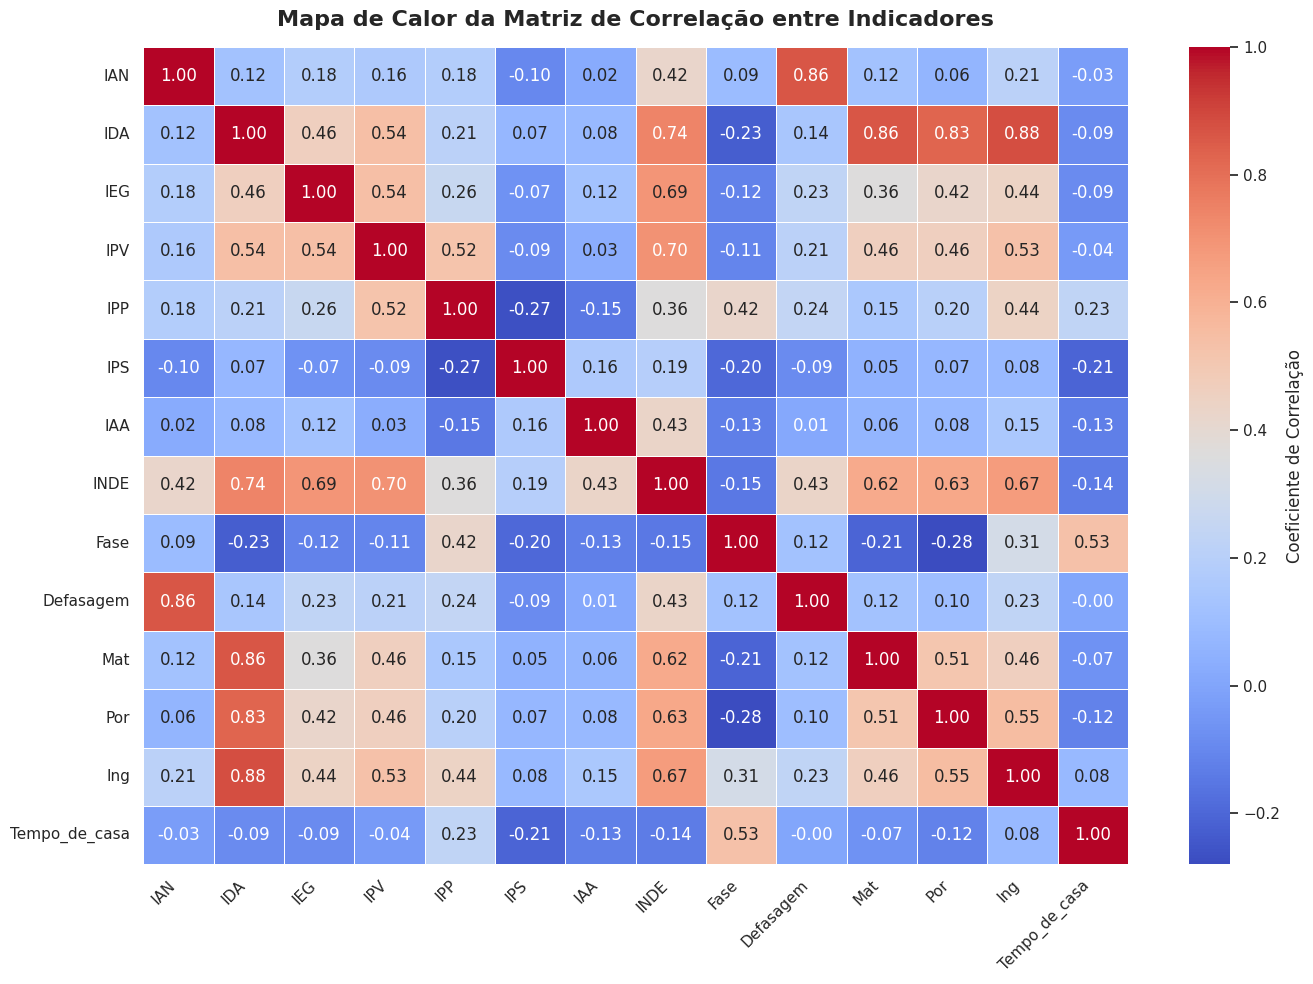

In [ ]:
plt.figure(figsize=(14, 10))
correlation_matrix = df_reprovacao[all_indicators].corr().round(2)
sns.heatmap(correlation_matrix,
            annot=True, # Mostrar os valores de correlação no mapa de calor
            cmap='coolwarm', # Escolher um colormap que destaque correlações positivas e negativas
            fmt=".2f", # Formatar os números para duas casas decimais
            linewidths=.5, # Adicionar linhas entre as células para melhor visualização
            cbar_kws={'label': 'Coeficiente de Correlação'}) # Legenda da barra de cores

plt.title('Mapa de Calor da Matriz de Correlação entre Indicadores', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Este mapa de calor visualiza as correlações de Pearson entre todos os indicadores analisados. Os valores próximos a 1 (vermelho forte) indicam uma forte correlação positiva, enquanto os valores próximos a -1 (azul forte) indicam uma forte correlação negativa. Valores próximos a 0 (tons neutros) sugerem pouca ou nenhuma correlação linear. Este gráfico ajuda a identificar rapidamente quais variáveis se movem juntas (ou em direções opostas) e a força dessas relações.

In [ ]:
df_reprovacao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1248 entries, 18 to 2476
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ano                      1248 non-null   int64  
 1   RA                       1248 non-null   int64  
 2   Ano de Nascimento        1248 non-null   int64  
 3   Gênero                   1248 non-null   object 
 4   Ano ingresso             1248 non-null   int64  
 5   Instituição de ensino    1248 non-null   object 
 6   Fase                     1248 non-null   int64  
 7   Fase Ideal               1248 non-null   int64  
 8   Defasagem                1248 non-null   int64  
 9   INDE                     1248 non-null   float64
 10  IAN                      1248 non-null   float64
 11  IDA                      1248 non-null   float64
 12  Mat                      1248 non-null   float64
 13  Por                      1248 non-null   float64
 14  Ing                      367

 ## Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

### 11.7 Seleção e Pré-processamento de Variáveis para o Modelo de Machine Learning

As variáveis para o modelo de machine learning serão conforme abaixo:

**Variável Alvo:**
*   `Aumento_Df_Ano_Seguinte`

**Variáveis que serão analisadas (Features - X):**
*   `IAN`
*   `IEG`
*   `IPS`
*   `Discrepancia_Percepcao` (calculada como `IDA - IAA`)
*   `Tempo_de_casa` (calculada como `Ano atual - Ano de ingresso no projeto`)
* `Instituição de ensino`

Os valores já existentes para `IEG` e `IPS` serão utilizados diretamente.

In [37]:
# Define a variável alvo (y)
y = df_reprovacao['Aumento_Df_Ano_Seguinte']

# Cria uma cópia do DataFrame para manipular as features
df_ml_features = df_reprovacao.copy()

# --- Criação/Recálculo das Variáveis Solicitadas ---

# Discrepancia_Percepcao (IDA - IAA)
df_ml_features['Discrepancia_Percepcao_Calculada'] = df_ml_features['IDA'] - df_ml_features['IAA']

# Tempo de casa (ano atual - ano de ingresso no projeto)
df_ml_features['Tempo_de_casa_Calculado'] = df_ml_features['Ano'] - df_ml_features['Ano ingresso']

# 4Transformando a Instituição de Ensino em variável numérica (1 = Escola Pública, 0 = Outros/Bolsista)
df_ml_features['Escola_Publica'] = np.where(df_ml_features['Instituição de ensino'] == 'Escola Pública', 1, 0)

# Define as features (X) a serem usadas no modelo com base na lista final fornecida pelo usuário
features_for_X = [
    #'Escola_Publica',
    'IAN',
    'IEG',
    'IPS',
    'Discrepancia_Percepcao_Calculada',
    'Tempo_de_casa_Calculado', # Corrigido o nome da coluna aqui
    #'IDA',
    #'IAA'
]
X = df_ml_features[features_for_X]

# Mapeamento para nomes de exibição mais curtos nos gráficos
feature_display_names = {
    'IAN': 'IAN',
    'IEG': 'IEG',
    'IPS': 'IPS',
    'Discrepancia_Percepcao_Calculada': 'Disc. Percepção',
    'Tempo_de_casa_Calculado': 'Tempo de Casa'
}

# Exibe as primeiras linhas do DataFrame de features processado
print("Features para o modelo de ML (X) conforme a nova definição:")
display(X.head())
print(f"\nShape das features (X): {X.shape}")
print(f"Shape da variável alvo (y): {y.shape}")

Features para o modelo de ML (X) conforme a nova definição:


,IAN,IEG,IPS,Discrepancia_Percepcao_Calculada,Tempo_de_casa_Calculado
18,5.0,9.5,7.5,0.1,0
27,5.0,7.6,8.1,8.0,6
33,10.0,5.2,8.8,-2.7,4
40,5.0,8.9,7.5,-0.6,5
42,10.0,4.8,6.9,6.9,5



Shape das features (X): (1248, 5)
Shape da variável alvo (y): (1248,)


In [ ]:
print("Distribuição da Variável Alvo (0 = Sem Risco, 1 = Em Risco):")
print(y.value_counts(normalize=True).round(3) * 100)
print(f"\nTotal de alunos aptos para o treinamento: {len(df_ml_features)}")

Distribuição da Variável Alvo (0 = Sem Risco, 1 = Em Risco):
Aumento_Df_Ano_Seguinte
0.0    81.9
1.0    18.1
Name: proportion, dtype: float64

Total de alunos aptos para o treinamento: 1248


In [ ]:
X.describe()

,IAN,IEG,IPS,Discrepancia_Percepcao_Calculada,Tempo_de_casa_Calculado
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000
mean,6.875000,8.619071,5.939696,-0.996554,1.565705
std,2.470759,1.179716,1.904059,3.302272,1.814716
min,2.500000,2.000000,2.500000,-8.000000,0.000000
25%,5.000000,8.100000,5.000000,-2.900000,0.000000
50%,5.000000,8.900000,6.895000,-1.600000,1.000000
75%,10.000000,9.500000,7.500000,-0.100000,3.000000
max,10.000000,10.000000,9.400000,9.900000,7.000000


In [ ]:
# Modificar todos os campos com mais de 3 anos de 'Tempo_de_casa_Calculado' para 3
df_ml_features.loc[df_ml_features['Tempo_de_casa_Calculado'] > 3, 'Tempo_de_casa_Calculado'] = 3

# O mesmo ajuste precisa ser feito na feature X para que o modelo use os valores corrigidos
X.loc[X['Tempo_de_casa_Calculado'] > 3, 'Tempo_de_casa_Calculado'] = 3

print("Valores de 'Tempo_de_casa_Calculado' ajustados para não exceder 3.")
display(X['Tempo_de_casa_Calculado'].value_counts().sort_index())

Valores de 'Tempo_de_casa_Calculado' ajustados para não exceder 3.


,count
Tempo_de_casa_Calculado,
0,503
1,287
2,107
3,351


### Separação de Dados e Treinamento do Modelo (Random Forest)

Para garantir que nosso modelo seja generalizável (ou seja, que ele funcione bem com alunos novos no futuro), dividiremos nossa base de dados em dois conjuntos:
*   **Dados de Treino (70%):** Exemplos que o algoritmo usará para "aprender" os padrões que levam um aluno à defasagem.
*   **Dados de Teste (30%):** Exemplos que o algoritmo nunca viu, usados para avaliarmos se as suas previsões são precisas.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Separando em Treino (70%) e Teste (30%)
# O parâmetro stratify=y garante que a proporção de alunos em risco seja igual no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Tamanho da base de Treino: {X_train.shape} alunos")
print(f"Tamanho da base de Teste:  {X_test.shape} alunos\n")

Tamanho da base de Treino: (873, 5) alunos
Tamanho da base de Teste:  (375, 5) alunos



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# Criamos um avaliador focado estritamente no Recall da classe 1 (Em Risco)
avaliador_recall_c1 = make_scorer(recall_score, pos_label=1)

# Forçamos limites saudáveis de profundidade (eliminamos o 'None')
parametros_ajustados = {
    'max_depth': [3, 4, 5, 6],          # Árvores controladas para evitar overfit
    'min_samples_leaf': [10, 15, 20],   # Exige grupos maiores de alunos por decisão
    'n_estimators': [100, 150, 200]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=parametros_ajustados,
    scoring=avaliador_recall_c1,        # <--- Força o modelo a caçar os alunos em risco
    cv=5
)
grid.fit(X_train, y_train)

# O verdadeiro melhor modelo para o seu problema:
melhor_rf = grid.best_estimator_
print("Novos Melhores parâmetros pedagógicos:", grid.best_params_)

Novos Melhores parâmetros pedagógicos: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 150}


=== Relatório de Classificação (Métricas de Acerto) ===
               precision    recall  f1-score   support

0 (Sem Risco)       0.92      0.81      0.86       307
 1 (Em Risco)       0.45      0.69      0.54        68

     accuracy                           0.79       375
    macro avg       0.68      0.75      0.70       375
 weighted avg       0.84      0.79      0.81       375



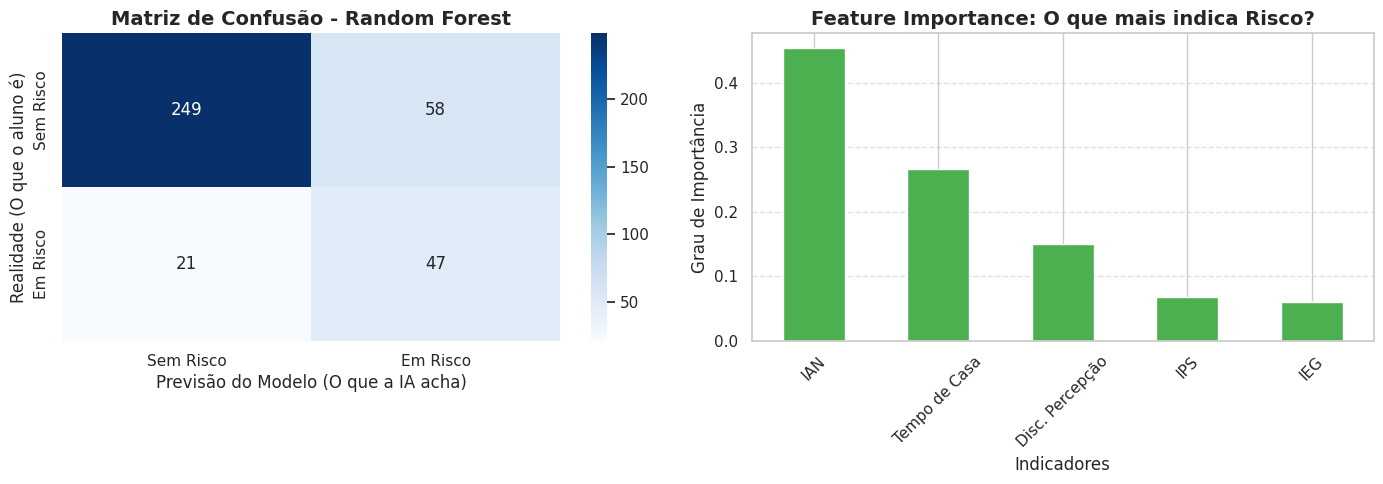

In [38]:
# 2. Instanciando e Treinando o Random Forest
# class_weight='balanced' ajuda o modelo a dar a devida atenção aos alunos sem risco (que são minoria)
#rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
#rf_model.fit(X_train, y_train)

# 2. Instanciando o Random Forest com Poda (Regularização)
rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight='balanced',  # Mantém o peso das classes
    max_depth=3,              # Evita que a árvore cresça demais e decore o treino
    min_samples_leaf=20,      # Exige pelo menos 10 alunos em cada decisão final
    max_features='sqrt'       # Limita quantas colunas cada árvore olha por vez
)
rf_model.fit(X_train, y_train)

# 3. Fazendo Previsões com a base de Teste
y_pred = rf_model.predict(X_test)

# 4. Avaliando o Modelo
print("=== Relatório de Classificação (Métricas de Acerto) ===")
print(classification_report(y_test, y_pred, target_names=['0 (Sem Risco)', '1 (Em Risco)']))

# 5. Plotando a Matriz de Confusão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred);
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Sem Risco', 'Em Risco'],
            yticklabels=['Sem Risco', 'Em Risco'])
ax1.set_title('Matriz de Confusão - Random Forest', fontweight='bold')
ax1.set_xlabel('Previsão do Modelo (O que a IA acha)')
ax1.set_ylabel('Realidade (O que o aluno é)')

# 6. Plotando a Importância das Variáveis (Feature Importance)
importancias = pd.Series(rf_model.feature_importances_, index=[feature_display_names[f] for f in features_for_X]).sort_values(ascending=False)

importancias.plot(kind='bar', color='#4CAF50', ax=ax2)
ax2.set_title('Feature Importance: O que mais indica Risco?', fontweight='bold')
ax2.set_ylabel('Grau de Importância')
ax2.set_xlabel('Indicadores')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Verificação de Overfitting (Treino vs Teste)
y_pred_treino = rf_model.predict(X_train) # ou xgb_model

from sklearn.metrics import recall_score
print("=== Checagem de Overfitting (Recall da Classe 1) ===")
print(f"Acerto no TREINO: {recall_score(y_train, y_pred_treino):.2%}")
print(f"Acerto no TESTE:  {recall_score(y_test, y_pred):.2%}")

=== Checagem de Overfitting (Recall da Classe 1) ===
Acerto no TREINO: 68.35%
Acerto no TESTE:  69.12%


In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, classification_report

# 1. Definir a validação cruzada estratificada
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definir o espaço de busca de hiperparâmetros mitigando overfitting
parametros_xgb = {
    'n_estimators': [80, 120, 150],
    'max_depth': [3, 4],                 # Árvores rasas evitam overfitting
    'learning_rate': [0.01, 0.05, 0.1],   # Taxas menores para aprendizado robusto
    'subsample': [0.7, 0.8],             # Amostragem de linhas
    'colsample_bytree': [0.7, 0.8],      # Amostragem de colunas
    'reg_lambda': [1.5, 3.0, 5.0],       # Penalidade L2
    'scale_pos_weight': [2.5, 3.5, 4.5]  # Suavização do peso da classe de risco
}

# 3. Instanciar o modelo base
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

# 4. Executar o Grid Search focado em melhorar o Recall da Classe 1 (Em Risco)
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_xgb,
    scoring='recall', # Foco em capturar os alunos em risco
    cv=cv_estratificado,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

# 5. Avaliar o melhor modelo encontrado
melhor_xgb = grid_xgb.best_estimator_
y_pred_novo = melhor_xgb.predict(X_test)

print("=== Novos Melhores Parâmetros ===")
print(grid_xgb.best_params_)

print("\n=== Novo Relatório de Classificação XGBoost ===")
print(classification_report(y_test, y_pred_novo))

# 6. Nova Checagem de Overfitting
y_pred_treino_novo = melhor_xgb.predict(X_train)
print("=== Checagem de Overfitting (Recall Classe 1) ===")
print(f"Acerto no TREINO: {recall_score(y_train, y_pred_treino_novo):.2%}")
print(f"Acerto no TESTE: {recall_score(y_test, y_pred_novo):.2%}")

=== Novos Melhores Parâmetros ===
{'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 80, 'reg_lambda': 5.0, 'scale_pos_weight': 4.5, 'subsample': 0.8}

=== Novo Relatório de Classificação XGBoost ===
              precision    recall  f1-score   support

         0.0       0.91      0.80      0.85       307
         1.0       0.42      0.65      0.51        68

    accuracy                           0.77       375
   macro avg       0.66      0.72      0.68       375
weighted avg       0.82      0.77      0.79       375

=== Checagem de Overfitting (Recall Classe 1) ===
Acerto no TREINO: 71.52%
Acerto no TESTE: 64.71%


=== Relatório de Classificação XGBoost ===
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86       307
         1.0       0.44      0.65      0.53        68

    accuracy                           0.79       375
   macro avg       0.68      0.73      0.70       375
weighted avg       0.83      0.79      0.80       375



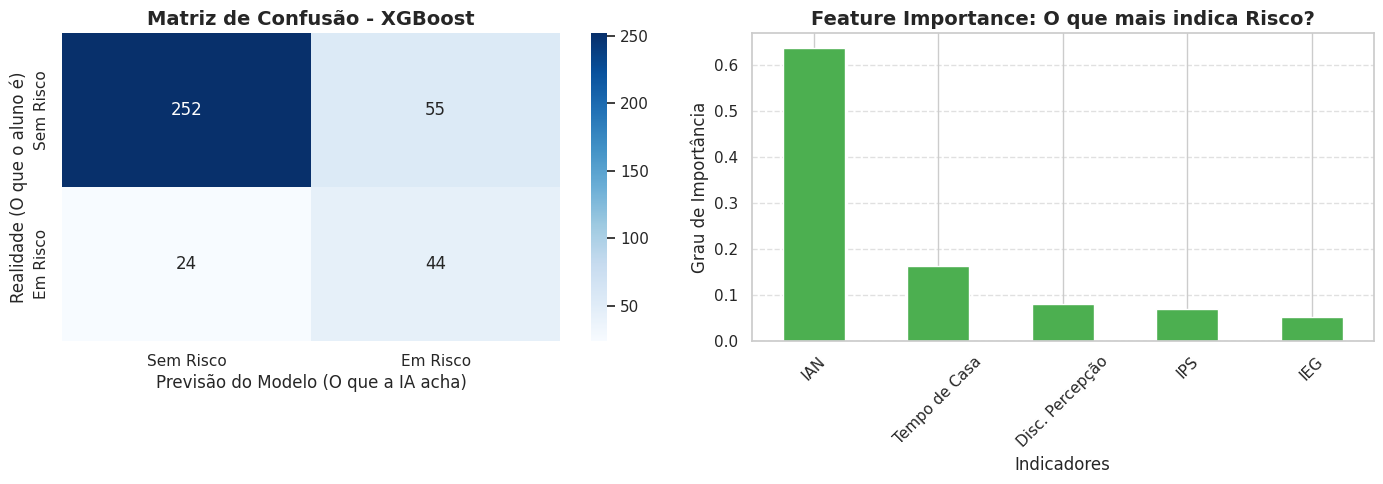

In [39]:
from xgboost import XGBClassifier


# Instanciando e Treinando o XGBoost
xgb_model = XGBClassifier(
    n_estimators=80,
    max_depth=3,                # Árvores um pouco mais rasas ajudam contra overfitting
    learning_rate=0.01,         # Passos menores de aprendizado para maior precisão
    scale_pos_weight=4.5, # Peso matemático na classe de risco
    random_state=42,
    eval_metric='logloss',
    colsample_bytree=0.8,
    reg_lambda=5.0,
    subsample=0.8
)

xgb_model.fit(X_train, y_train)

# 4. Avaliando o Modelo nas métricas de Teste
y_pred = xgb_model.predict(X_test)
print("=== Relatório de Classificação XGBoost ===")
print(classification_report(y_test, y_pred))

# 5. Plotando a Matriz de Confusão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Sem Risco', 'Em Risco'],
            yticklabels=['Sem Risco', 'Em Risco'])
ax1.set_title('Matriz de Confusão - XGBoost', fontweight='bold')
ax1.set_xlabel('Previsão do Modelo (O que a IA acha)')
ax1.set_ylabel('Realidade (O que o aluno é)')

# 6. Plotando a Importância das Variáveis (Feature Importance)
importancias = pd.Series(xgb_model.feature_importances_, index=[feature_display_names[f] for f in features_for_X]).sort_values(ascending=False)

importancias.plot(kind='bar', color='#4CAF50', ax=ax2)
ax2.set_title('Feature Importance: O que mais indica Risco?', fontweight='bold')
ax2.set_ylabel('Grau de Importância')
ax2.set_xlabel('Indicadores')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Verificação de Overfitting (Treino vs Teste)
y_pred_treino = xgb_model.predict(X_train)

print("=== Checagem de Overfitting (Recall da Classe 1) ===")
print(f"Acerto no TREINO: {recall_score(y_train, y_pred_treino):.2%}")
print(f"Acerto no TESTE:  {recall_score(y_test, y_pred):.2%}")

=== Checagem de Overfitting (Recall da Classe 1) ===
Acerto no TREINO: 68.99%
Acerto no TESTE:  64.71%


In [ ]:
import joblib

# Salvando o modelo treinado em um arquivo .pkl
joblib.dump(rf_model, 'modelo_passos_magicos.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


### Conclusão: Justificativa da Escolha do Modelo para Exportação

A escolha do rf_model (Random Forest) para exportação, conforme demonstrado na pipeline, pode ser justificada pelos seguintes pontos, comparando-o com os resultados do XGBoost:

Recall da Classe 1 (Alunos em Risco): O objetivo principal é identificar alunos em risco. O rf_model alcançou um recall de 69.12% no conjunto de teste para a classe 'Em Risco'. Comparativamente, os modelos XGBoost otimizados alcançaram recalls de 64.71% e 65%. Embora a diferença não seja gigantesca, o Random Forest apresentou um desempenho ligeiramente superior na métrica mais crítica para este problema.

Generalização e Overfitting: O rf_model demonstrou uma excelente capacidade de generalização. Na checagem de overfitting, o recall da classe 1 foi de 68.35% no treino e 69.12% no teste. Essa proximidade entre os resultados de treino e teste indica que o modelo não está superajustado aos dados de treinamento, sendo mais robusto para prever novos casos. Os modelos XGBoost, por outro lado, mostraram uma pequena queda no recall do treino para o teste (por exemplo, 71.52% no treino vs. 64.71% no teste), sugerindo um ligeiro overfitting que o Random Forest conseguiu evitar melhor.

Interpretabilidade: Embora ambos sejam modelos baseados em árvores e ofereçam importância de características, para alguns cenários, o Random Forest pode ser percebido como marginalmente mais intuitivo em termos de como as decisões são agregadas. A estabilidade na performance de generalização também contribui para a confiança na interpretabilidade de suas decisões.

Em resumo, a escolha do rf_model se baseia na sua capacidade de identificar uma maior proporção de alunos em risco (recall superior) e na sua comprovada robustez contra o overfitting, garantindo que o modelo funcionará de forma confiável ao ser aplicado a novos dados no Streamlit.